北京市新冠肺炎确诊数预测

下表是 2020 年 1 月 20 日起 19 天的北京市新冠肺炎**累计确诊数**，请预测未来 10 天的确诊人数。

| 天数 | 1    | 2    | 3    | 4    | 5    | 6    | 7    | 8    | 9    | 10   | 11   | 12   | 13   | 14   | 15   | 16   | 17   | 18   | 19   |
| ---- | ---- | ---- | ---- | ---- | ---- | ---- | ---- | ---- | ---- | ---- | ---- | ---- | ---- | ---- | ---- | ---- | ---- | ---- | ---- |
| 人数 | 14   | 22   | 36   | 41   | 68   | 80   | 91   | 111  | 114  | 139  | 168  | 191  | 212  | 228  | 253  | 274  | 297  | 315  | 326  |



In [8]:
# 北京市新冠肺炎累计确诊数（2020.1.20 起，共 19 天）
days = list(range(1, 20))
cases = [14, 22, 36, 41, 68, 80, 91, 111, 114, 139,
         168, 191, 212, 228, 253, 274, 297, 315, 326]

print(f"天数: {days}")
print(f"累计确诊: {cases}")


天数: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
累计确诊: [14, 22, 36, 41, 68, 80, 91, 111, 114, 139, 168, 191, 212, 228, 253, 274, 297, 315, 326]


In [9]:
from scipy.optimize import curve_fit
def f(x, k, b):
    return k*x+b
res = curve_fit(f=f, xdata=days, ydata=cases)
print(res)


(array([ 18.37017544, -26.85964912]), array([[ 0.23575018, -2.35750184],
       [-2.35750184, 30.6475241 ]]))


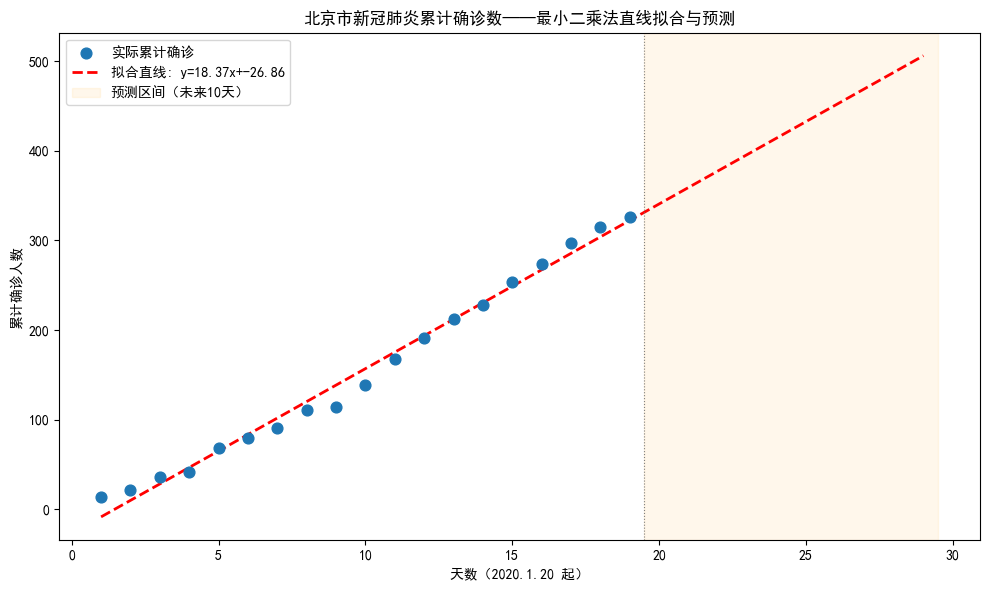

未来 10 天预测（累计确诊）：
  第 20 天: 341
  第 21 天: 359
  第 22 天: 377
  第 23 天: 396
  第 24 天: 414
  第 25 天: 432
  第 26 天: 451
  第 27 天: 469
  第 28 天: 488
  第 29 天: 506


In [10]:
import matplotlib.pyplot as plt

# 字体设置(适配中文)
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# ==================== 可视化拟合结果 ====================
k_fit, b_fit = res[0]  # curve_fit 返回 (最优参数, 协方差矩阵)

# 预测未来 10 天
days_future = list(range(1, 30))          # 1~29 天
cases_fit = [f(d, k_fit, b_fit) for d in days_future]

plt.figure(figsize=(10, 6))

# 原始数据
plt.scatter(days, cases, c='#1f77b4', s=60, zorder=3, label='实际累计确诊')

# 拟合曲线（含预测部分）
plt.plot(days_future, cases_fit, 'r--', linewidth=2, label=f'拟合直线: y={k_fit:.2f}x+{b_fit:.2f}')

# 预测区域标记
plt.axvspan(19.5, 29.5, alpha=0.08, color='orange', label='预测区间（未来10天）')
plt.axvline(x=19.5, color='gray', linewidth=0.8, linestyle=':')

plt.xlabel('天数（2020.1.20 起）')
plt.ylabel('累计确诊人数')
plt.title('北京市新冠肺炎累计确诊数——最小二乘法直线拟合与预测')
plt.legend()
plt.tight_layout()
plt.show()

# 打印预测值
print("未来 10 天预测（累计确诊）：")
for d in range(20, 30):
    pred = f(d, k_fit, b_fit)
    print(f"  第 {d:2d} 天: {pred:.0f}")